# Data Visualization for Anomaly Detection

Create histograms, boxplots, scatter plots, and time series visualizations to understand network traffic patterns.

## 1. Setup and Data Creation

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../')
from src import data_cleaning, feature_engineering, statistical_analysis

np.random.seed(42)

# Generate synthetic network traffic
n_normal = 800
n_anomalies = 200

# Normal traffic
normal_data = {
    'Flow Duration': np.random.exponential(500, n_normal),
    'Total Packets': np.random.poisson(8, n_normal),
    'Bytes Sent': np.random.normal(2000, 500, n_normal),
    'Type': ['Normal'] * n_normal
}

# Anomalous traffic (attacks)
anomaly_data = {
    'Flow Duration': np.random.exponential(50, n_anomalies),
    'Total Packets': np.random.poisson(200, n_anomalies),
    'Bytes Sent': np.random.normal(50000, 10000, n_anomalies),
    'Type': ['Anomalous'] * n_anomalies
}

df_normal = pd.DataFrame(normal_data)
df_anomaly = pd.DataFrame(anomaly_data)
df = pd.concat([df_normal, df_anomaly], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset: {len(df)} flows ({n_normal} normal, {n_anomalies} anomalous)")
print(df.head())

Dataset: 1000 flows (800 normal, 200 anomalous)
   Flow Duration  Total Packets   Bytes Sent    Type
0     239.736850              8  2031.770025  Normal
1     848.041331             12  2857.082179  Normal
2     310.580530              9  1460.045080  Normal
3     220.103380              9  2846.662818  Normal
4    1498.486192              7  1188.767335  Normal


## 2. Histogram - Distribution Comparison

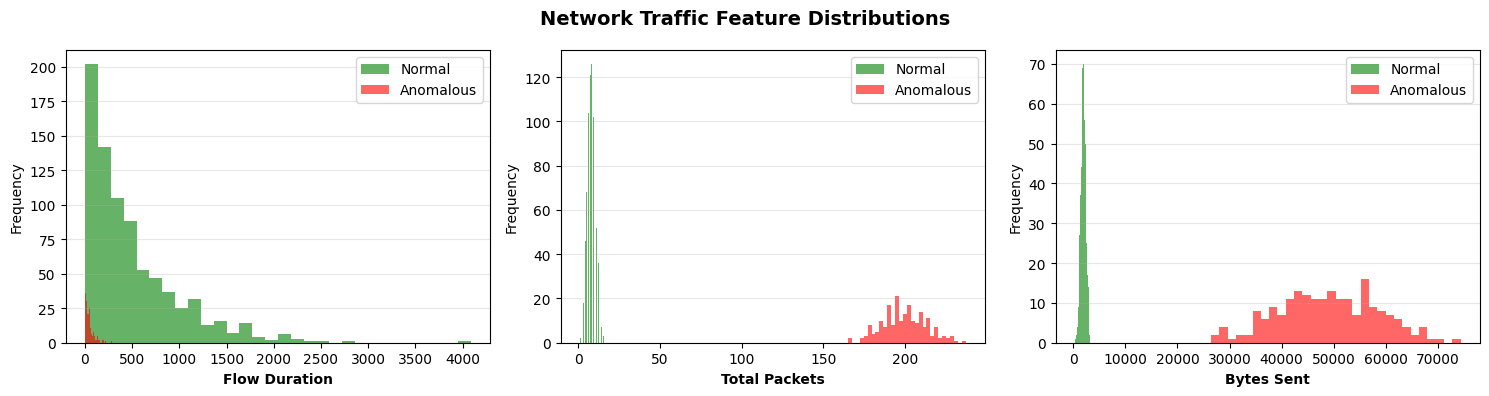

✓ Histograms show clear separation between normal and anomalous patterns


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Network Traffic Feature Distributions', fontsize=14, fontweight='bold')

normal = df[df['Type'] == 'Normal']
anomalies = df[df['Type'] == 'Anomalous']

features = ['Flow Duration', 'Total Packets', 'Bytes Sent']

for idx, feature in enumerate(features):
    axes[idx].hist(normal[feature], bins=30, alpha=0.6, label='Normal', color='green')
    axes[idx].hist(anomalies[feature], bins=30, alpha=0.6, label='Anomalous', color='red')
    axes[idx].set_xlabel(feature, fontweight='bold')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Histograms show clear separation between normal and anomalous patterns")

## 3. Boxplots - Quartile Analysis

C:\Users\ain kay\AppData\Local\Temp\ipykernel_11312\2207083005.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['Normal', 'Anomalous'], patch_artist=True)
C:\Users\ain kay\AppData\Local\Temp\ipykernel_11312\2207083005.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['Normal', 'Anomalous'], patch_artist=True)
C:\Users\ain kay\AppData\Local\Temp\ipykernel_11312\2207083005.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['Normal', 'Anomalous'], patch_artist=True)


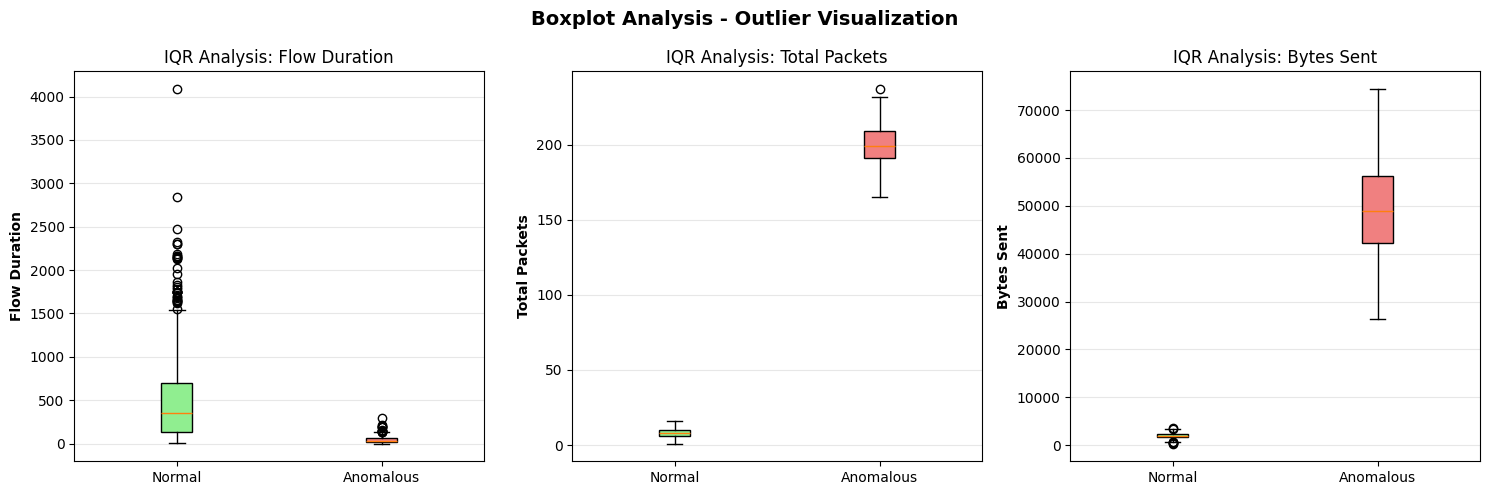

✓ Boxplots reveal IQR bounds and potential outliers (circles)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Boxplot Analysis - Outlier Visualization', fontsize=14, fontweight='bold')

for idx, feature in enumerate(features):
    data_to_plot = [normal[feature], anomalies[feature]]
    bp = axes[idx].boxplot(data_to_plot, labels=['Normal', 'Anomalous'], patch_artist=True)
    
    # Color the boxes
    colors = ['lightgreen', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    axes[idx].set_ylabel(feature, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].set_title(f'IQR Analysis: {feature}')

plt.tight_layout()
plt.show()

print("✓ Boxplots reveal IQR bounds and potential outliers (circles)")

## 4. Scatter Plot - Bivariate Analysis

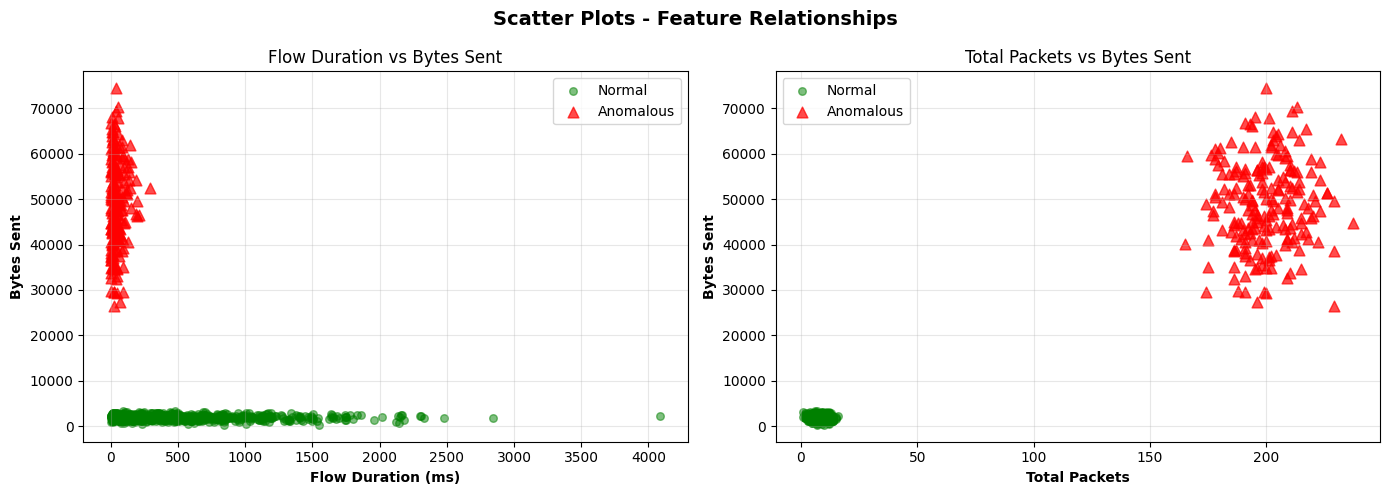

✓ Scatter plots reveal anomalies in high feature values


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Scatter Plots - Feature Relationships', fontsize=14, fontweight='bold')

# Scatter 1: Flow Duration vs Bytes Sent
axes[0].scatter(normal['Flow Duration'], normal['Bytes Sent'], 
               alpha=0.5, s=30, c='green', label='Normal')
axes[0].scatter(anomalies['Flow Duration'], anomalies['Bytes Sent'], 
               alpha=0.7, s=60, c='red', label='Anomalous', marker='^')
axes[0].set_xlabel('Flow Duration (ms)', fontweight='bold')
axes[0].set_ylabel('Bytes Sent', fontweight='bold')
axes[0].set_title('Flow Duration vs Bytes Sent')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter 2: Total Packets vs Bytes Sent
axes[1].scatter(normal['Total Packets'], normal['Bytes Sent'], 
               alpha=0.5, s=30, c='green', label='Normal')
axes[1].scatter(anomalies['Total Packets'], anomalies['Bytes Sent'], 
               alpha=0.7, s=60, c='red', label='Anomalous', marker='^')
axes[1].set_xlabel('Total Packets', fontweight='bold')
axes[1].set_ylabel('Bytes Sent', fontweight='bold')
axes[1].set_title('Total Packets vs Bytes Sent')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Scatter plots reveal anomalies in high feature values")

## 5. Time Series Plot

C:\Users\ain kay\AppData\Local\Temp\ipykernel_11312\1037362741.py:2: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['Timestamp'] = pd.date_range('2024-01-01', periods=len(df), freq='1S')


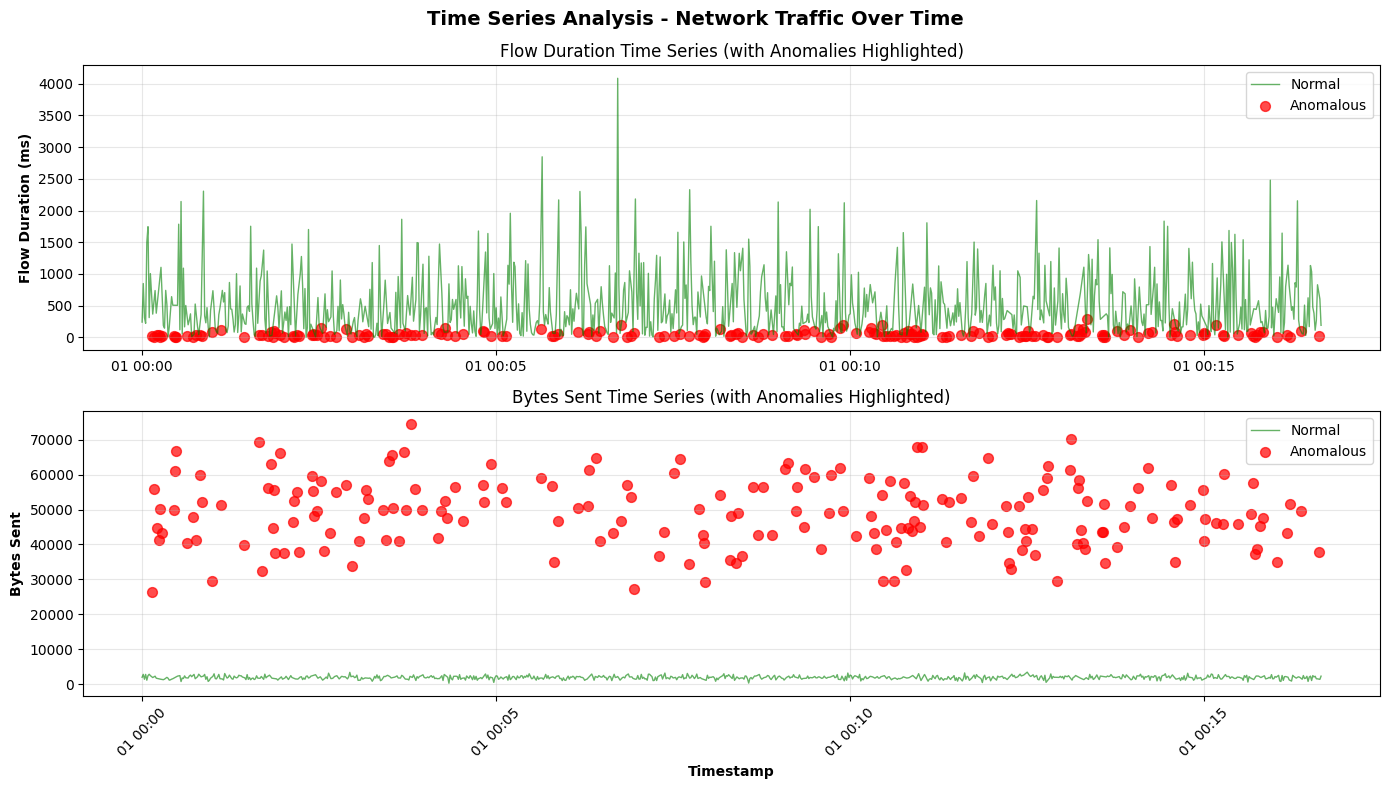

✓ Time series reveals temporal patterns and sudden anomaly spikes


In [5]:
# Create time-indexed data
df['Timestamp'] = pd.date_range('2024-01-01', periods=len(df), freq='1S')
df_sorted = df.sort_values('Timestamp')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Time Series Analysis - Network Traffic Over Time', fontsize=14, fontweight='bold')

# Plot 1: Flow Duration over time
normal_ts = df_sorted[df_sorted['Type'] == 'Normal']
anomaly_ts = df_sorted[df_sorted['Type'] == 'Anomalous']

axes[0].plot(normal_ts['Timestamp'], normal_ts['Flow Duration'], 
            'g-', alpha=0.6, linewidth=1, label='Normal')
axes[0].scatter(anomaly_ts['Timestamp'], anomaly_ts['Flow Duration'], 
               c='red', s=50, alpha=0.7, label='Anomalous')
axes[0].set_ylabel('Flow Duration (ms)', fontweight='bold')
axes[0].set_title('Flow Duration Time Series (with Anomalies Highlighted)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Bytes Sent over time
axes[1].plot(normal_ts['Timestamp'], normal_ts['Bytes Sent'], 
            'g-', alpha=0.6, linewidth=1, label='Normal')
axes[1].scatter(anomaly_ts['Timestamp'], anomaly_ts['Bytes Sent'], 
               c='red', s=50, alpha=0.7, label='Anomalous')
axes[1].set_xlabel('Timestamp', fontweight='bold')
axes[1].set_ylabel('Bytes Sent', fontweight='bold')
axes[1].set_title('Bytes Sent Time Series (with Anomalies Highlighted)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✓ Time series reveals temporal patterns and sudden anomaly spikes")

## 6. Heatmap - Correlation Matrix

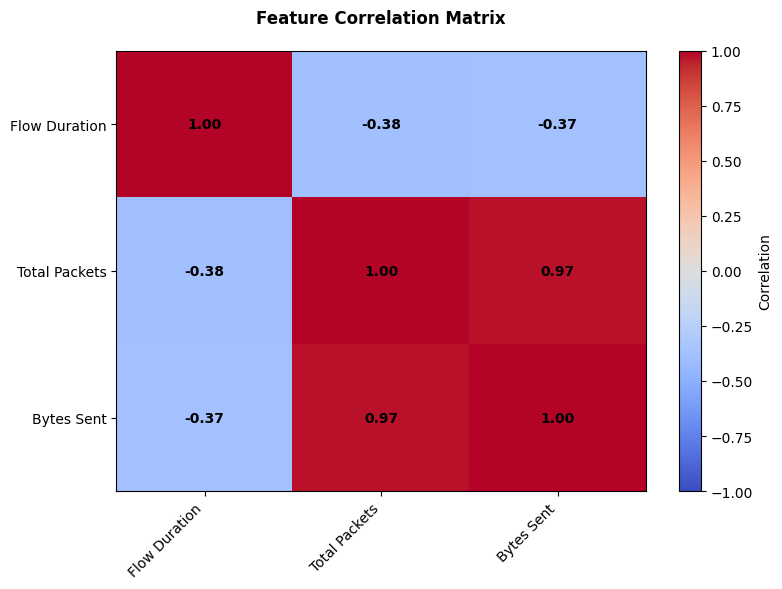


Correlation Matrix:
               Flow Duration  Total Packets  Bytes Sent
Flow Duration       1.000000      -0.377276   -0.367730
Total Packets      -0.377276       1.000000    0.972057
Bytes Sent         -0.367730       0.972057    1.000000


In [6]:
# Compute correlation
numeric_df = df[['Flow Duration', 'Total Packets', 'Bytes Sent']]
correlation = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlation, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(correlation.columns)))
ax.set_yticks(np.arange(len(correlation.columns)))
ax.set_xticklabels(correlation.columns, rotation=45, ha='right')
ax.set_yticklabels(correlation.columns)

# Add correlation values
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        text = ax.text(j, i, f'{correlation.iloc[i, j]:.2f}',
                       ha='center', va='center', color='black', fontweight='bold')

ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=20)
plt.colorbar(im, ax=ax, label='Correlation')
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(correlation)

## 7. Cumulative Distribution Function

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cumulative Distribution - Anomaly Separation', fontsize=14, fontweight='bold')

# CDF for Flow Duration
normal_sorted = np.sort(normal['Flow Duration'])
anomaly_sorted = np.sort(anomalies['Flow Duration'])

axes[0].plot(normal_sorted, np.arange(1, len(normal_sorted)+1)/len(normal_sorted), 
            'g-', linewidth=2, label='Normal', alpha=0.7)
axes[0].plot(anomaly_sorted, np.arange(1, len(anomaly_sorted)+1)/len(anomaly_sorted), 
            'r-', linewidth=2, label='Anomalous', alpha=0.7)
axes[0].set_xlabel('Flow Duration (ms)', fontweight='bold')
axes[0].set_ylabel('Cumulative Probability')
axes[0].set_title('CDF: Flow Duration')
axes[0].legend()
axes[0].grid(alpha=0.3)

# CDF for Bytes Sent
normal_bytes = np.sort(normal['Bytes Sent'])
anomaly_bytes = np.sort(anomalies['Bytes Sent'])

axes[1].plot(normal_bytes, np.arange(1, len(normal_bytes)+1)/len(normal_bytes), 
            'g-', linewidth=2, label='Normal', alpha=0.7)
axes[1].plot(anomaly_bytes, np.arange(1, len(anomaly_bytes)+1)/len(anomaly_bytes), 
            'r-', linewidth=2, label='Anomalous', alpha=0.7)
axes[1].set_xlabel('Bytes Sent', fontweight='bold')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('CDF: Bytes Sent')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ CDF shows clear separation between normal and anomalous distributions")

## Summary

- **Histograms**: Compare feature distributions
- **Boxplots**: Visualize quartiles and outliers (IQR method)
- **Scatter Plots**: Show relationships between features
- **Time Series**: Detect temporal anomalies
- **Correlation**: Understand feature dependencies
- **CDF**: Probability-based anomaly separation

Visualization enables both exploration and explanation of anomalies!